## Construcción de grafo usuario-producto. Calcular densidad, diámetro inicial. 

In [1]:
# !pip install pandas tqdm

## 1. Importaciones

In [2]:
import time
import pandas as pd
import json
from implementaciones.preprocessing import load_reviews_efficiently, load_business_efficiently, perform_exhaustive_cleaning, get_descriptive_statistics, plot_exploratory_charts, build_user_product_graph
from implementaciones.graphs import BipartiteGraph
from implementaciones.export_presentation_data import export_data_for_web
from implementaciones.export_presentation_data import export_elbow_data

## 2. Análisis Exploratorio de Datos (EDA) y Limpieza
A continuación se definen las rutas de los archivos originales y se ejecuta el proceso de limpieza y análisis exploratorio general (usando una muestra representativa de reseñas obtenida por Reservoir Sampling para los gráficos iniciales).

1. Cargando datos de negocios de forma eficiente...


Cargando negocios: 150346it [00:00, 184297.79it/s]


   Negocios leídos originalmente: 150,346

2. Cargando muestra de reseñas mediante Reservoir Sampling...


Reservoir Sampling de reseñas: 6990280it [00:10, 661296.58it/s]


   Reseñas leídas originalmente (temporal): 299,675

3. Ejecutando limpieza exhaustiva y normalización...

=== REPORTE DE LIMPIEZA Y NORMALIZACIÓN ===
• Reseñas iniciales: 299,675
  - Reseñas eliminadas por NaN críticos: 0
  - Reseñas duplicadas eliminadas: 214
  - Reseñas con estrellas inválidas eliminadas: 0
  - Reseñas huérfanas eliminadas (sin negocio asociado): 0
• Reseñas finales tras limpieza: 299,461
--------------------------------------------------
• Negocios iniciales: 150,346
  - Negocios eliminados por NaN críticos: 0
  - Negocios duplicados eliminados: 0
  - Categorías de negocios imputadas (NaN -> Uncategorized): 103
  - Negocios con estrellas inválidas eliminadas: 0
• Negocios finales tras limpieza: 150,346
--------------------------------------------------
• Umbral de outliers para Review Count de Negocios (IQR): 80.50
• Cantidad de negocios atípicos (outliers de alto volumen): 18,302

4. Seleccionando muestra final de 100,000 reseñas para la exploración visual...
   M

,state,count,mean_stars,median_stars,mean_review_count
0,PA,34039,3.573019,3.5,45.265431
1,FL,26330,3.610957,4.0,42.534220
2,TN,12056,3.571500,3.5,49.618033
3,IN,11247,3.588246,4.0,42.016982
4,MO,10913,3.546092,3.5,44.341336



6. Generando y guardando gráficos exploratorios del EDA...

Distribución de calificaciones (Stars):


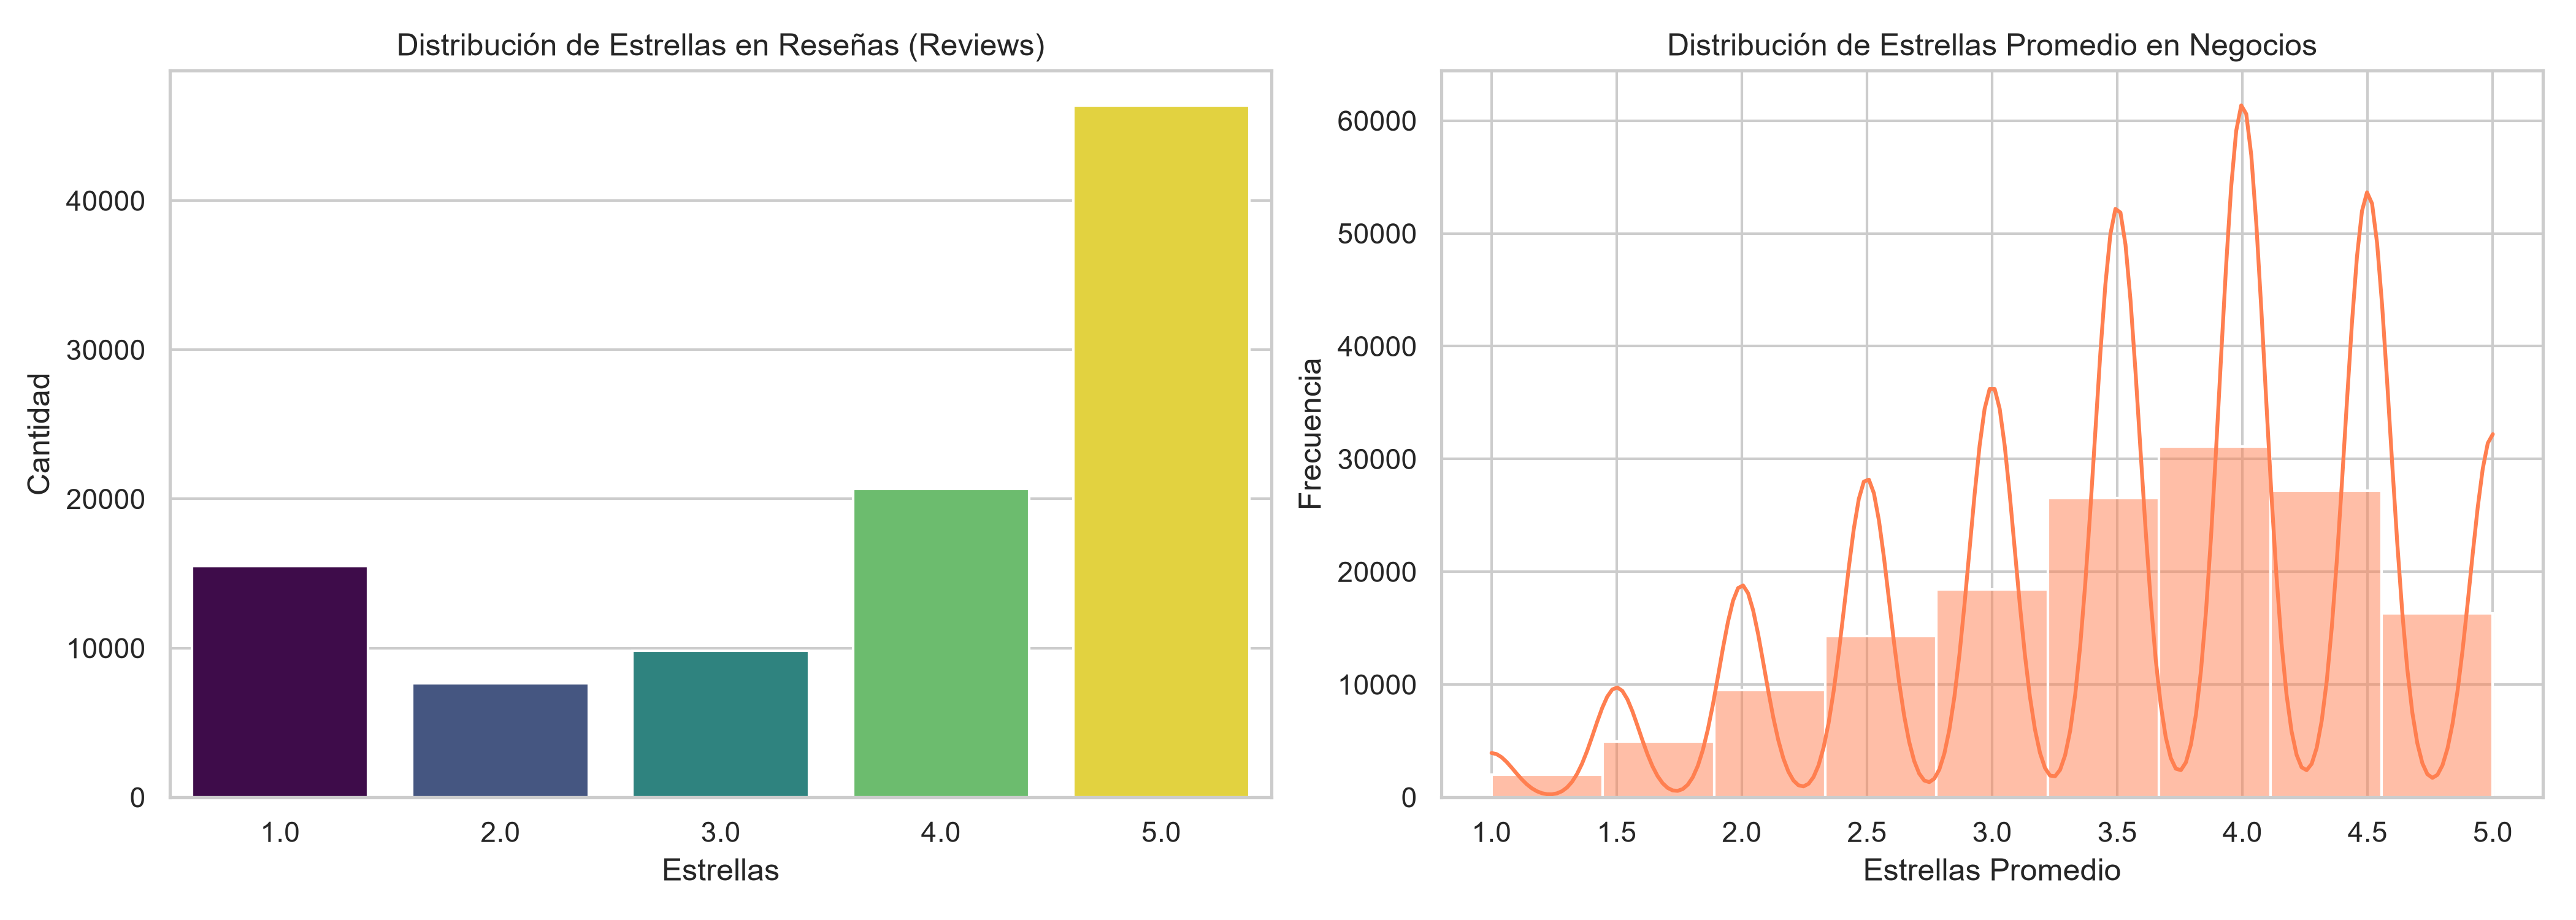


Distribución del volumen de reseñas por negocio:


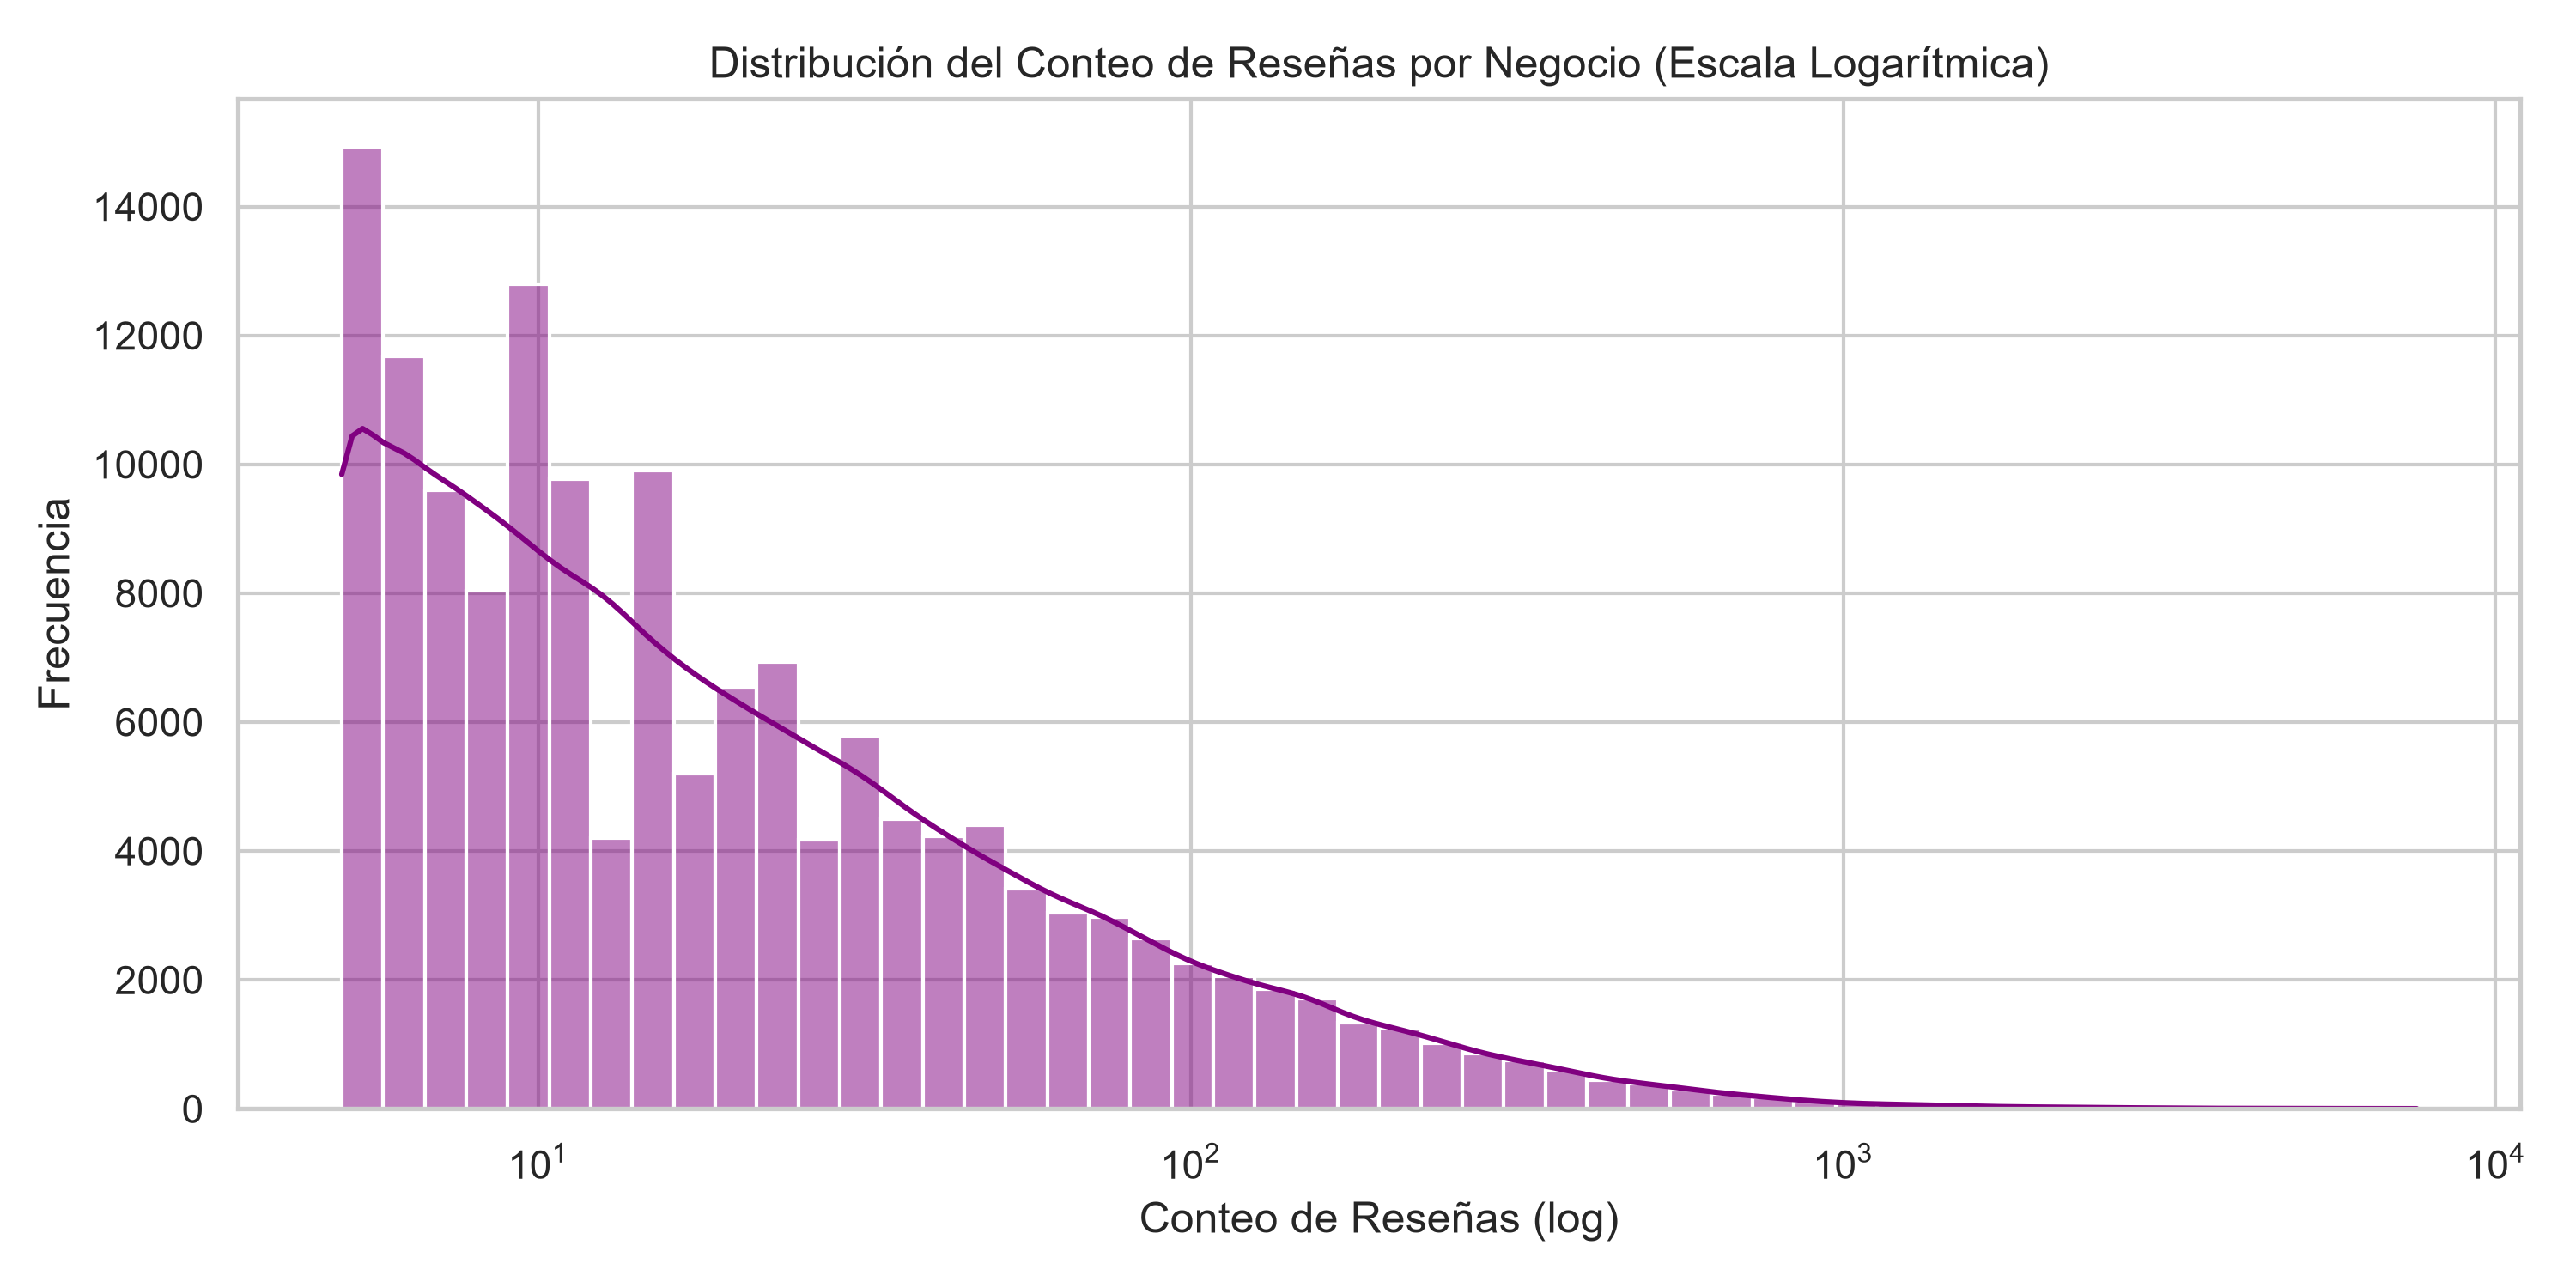


Top 15 categorías de negocio más populares:


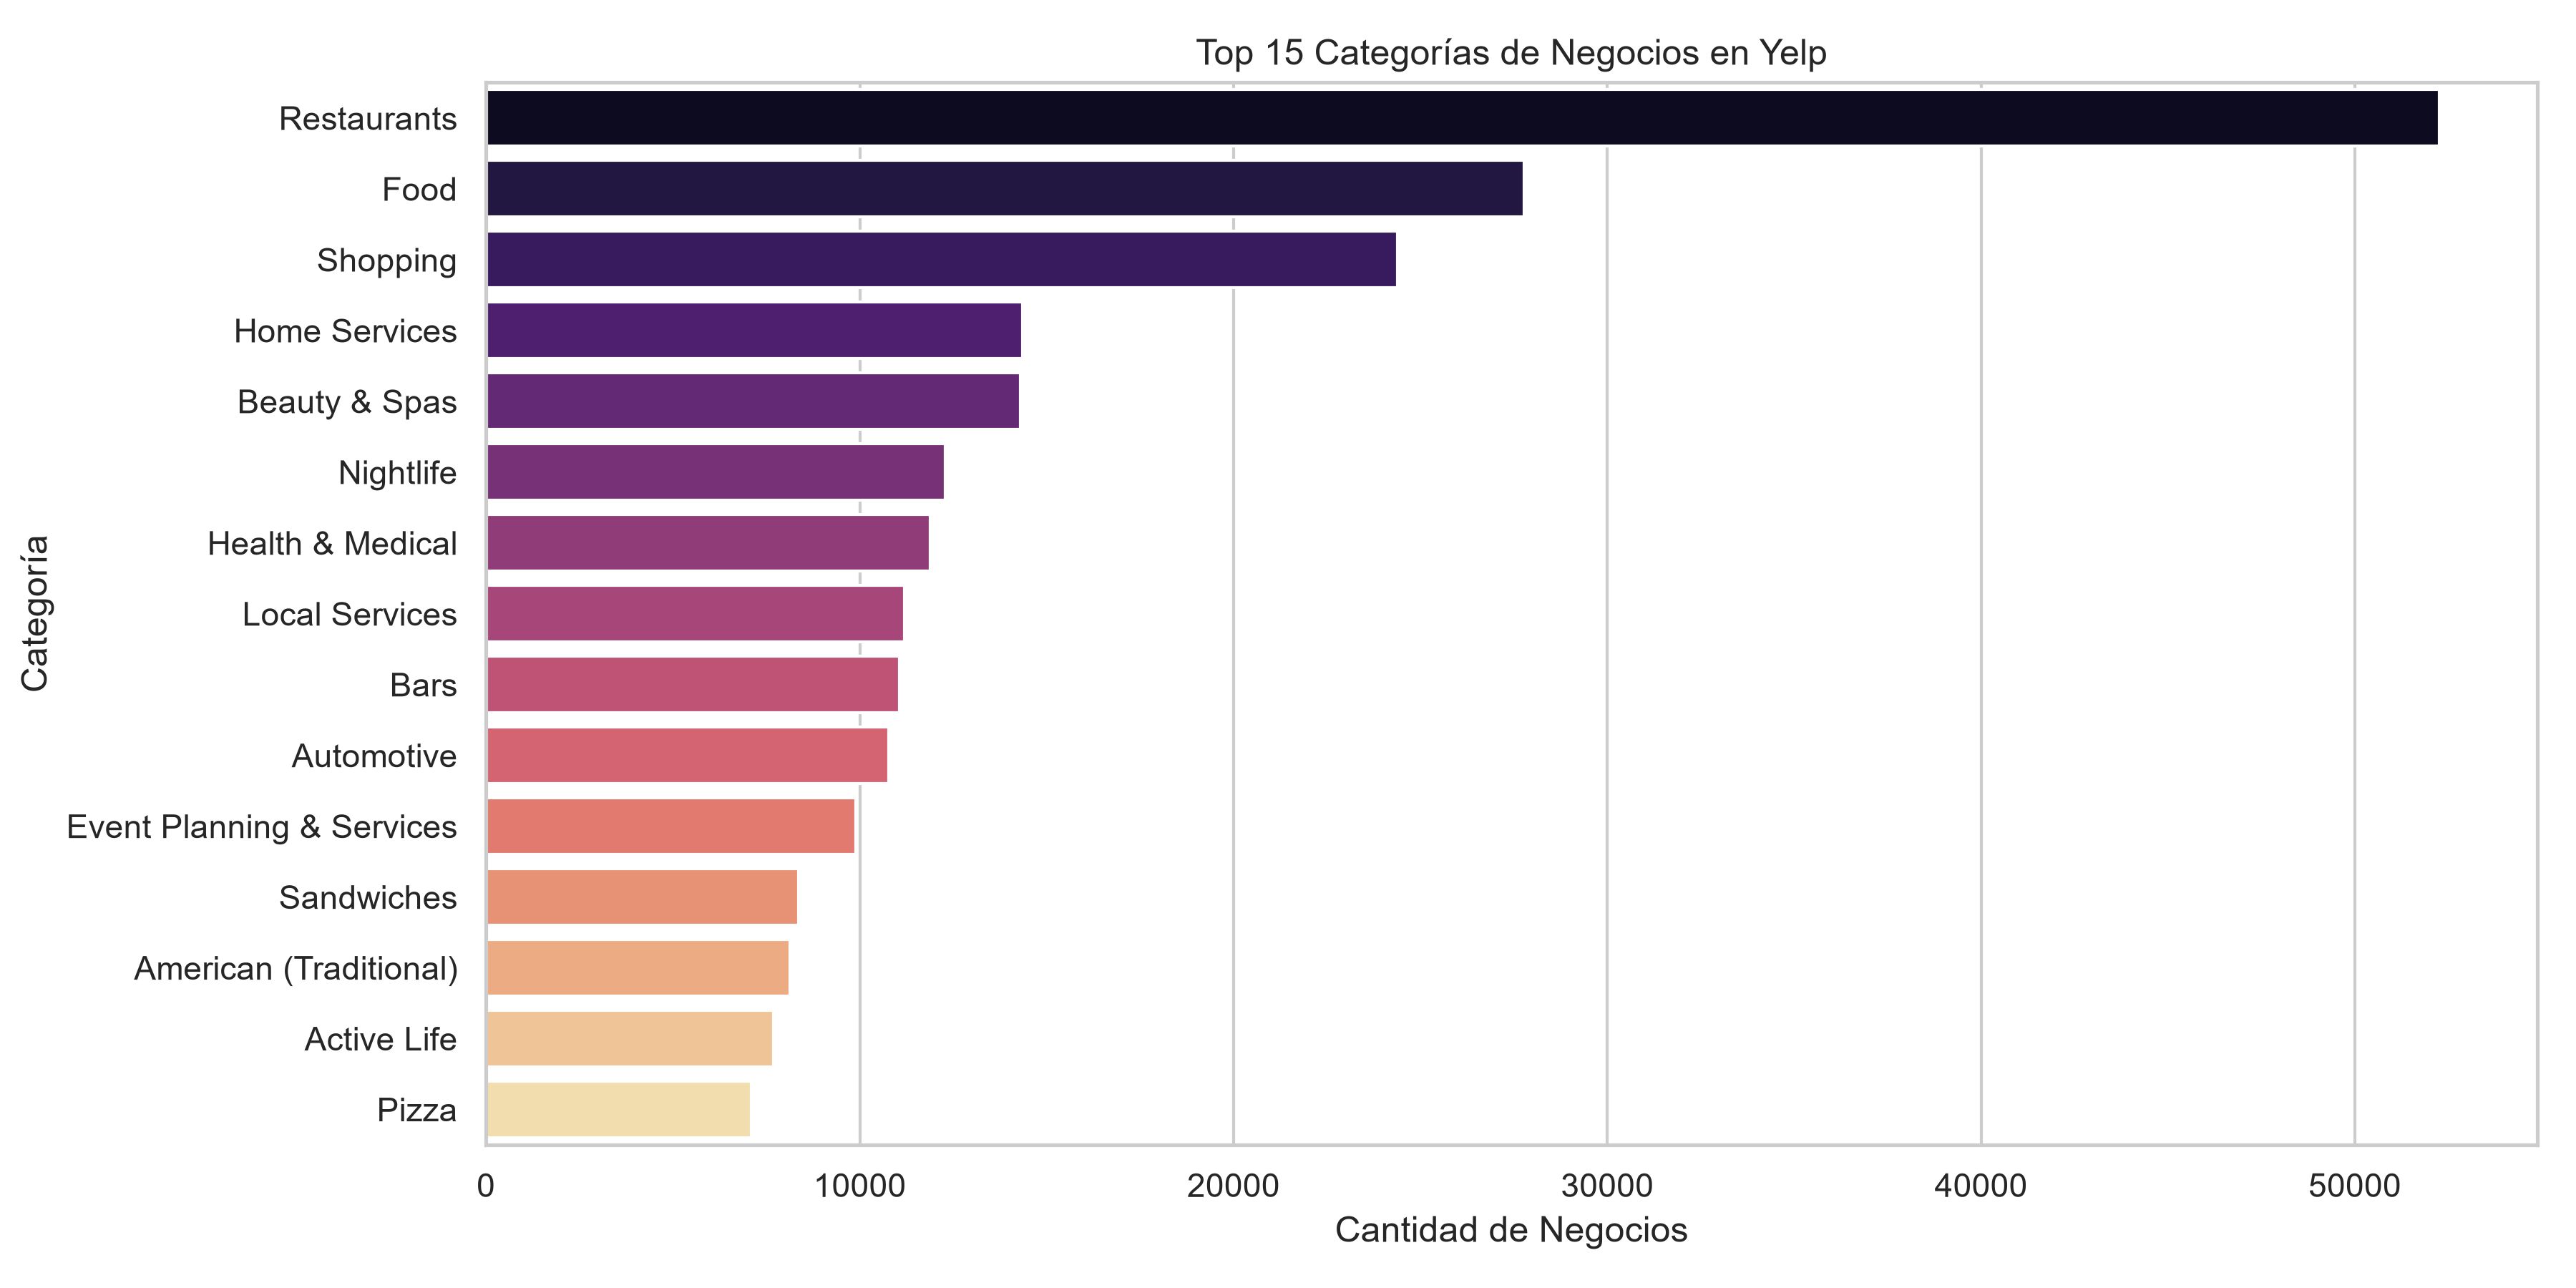


Relación entre Calificaciones y Volumen de Reseñas:


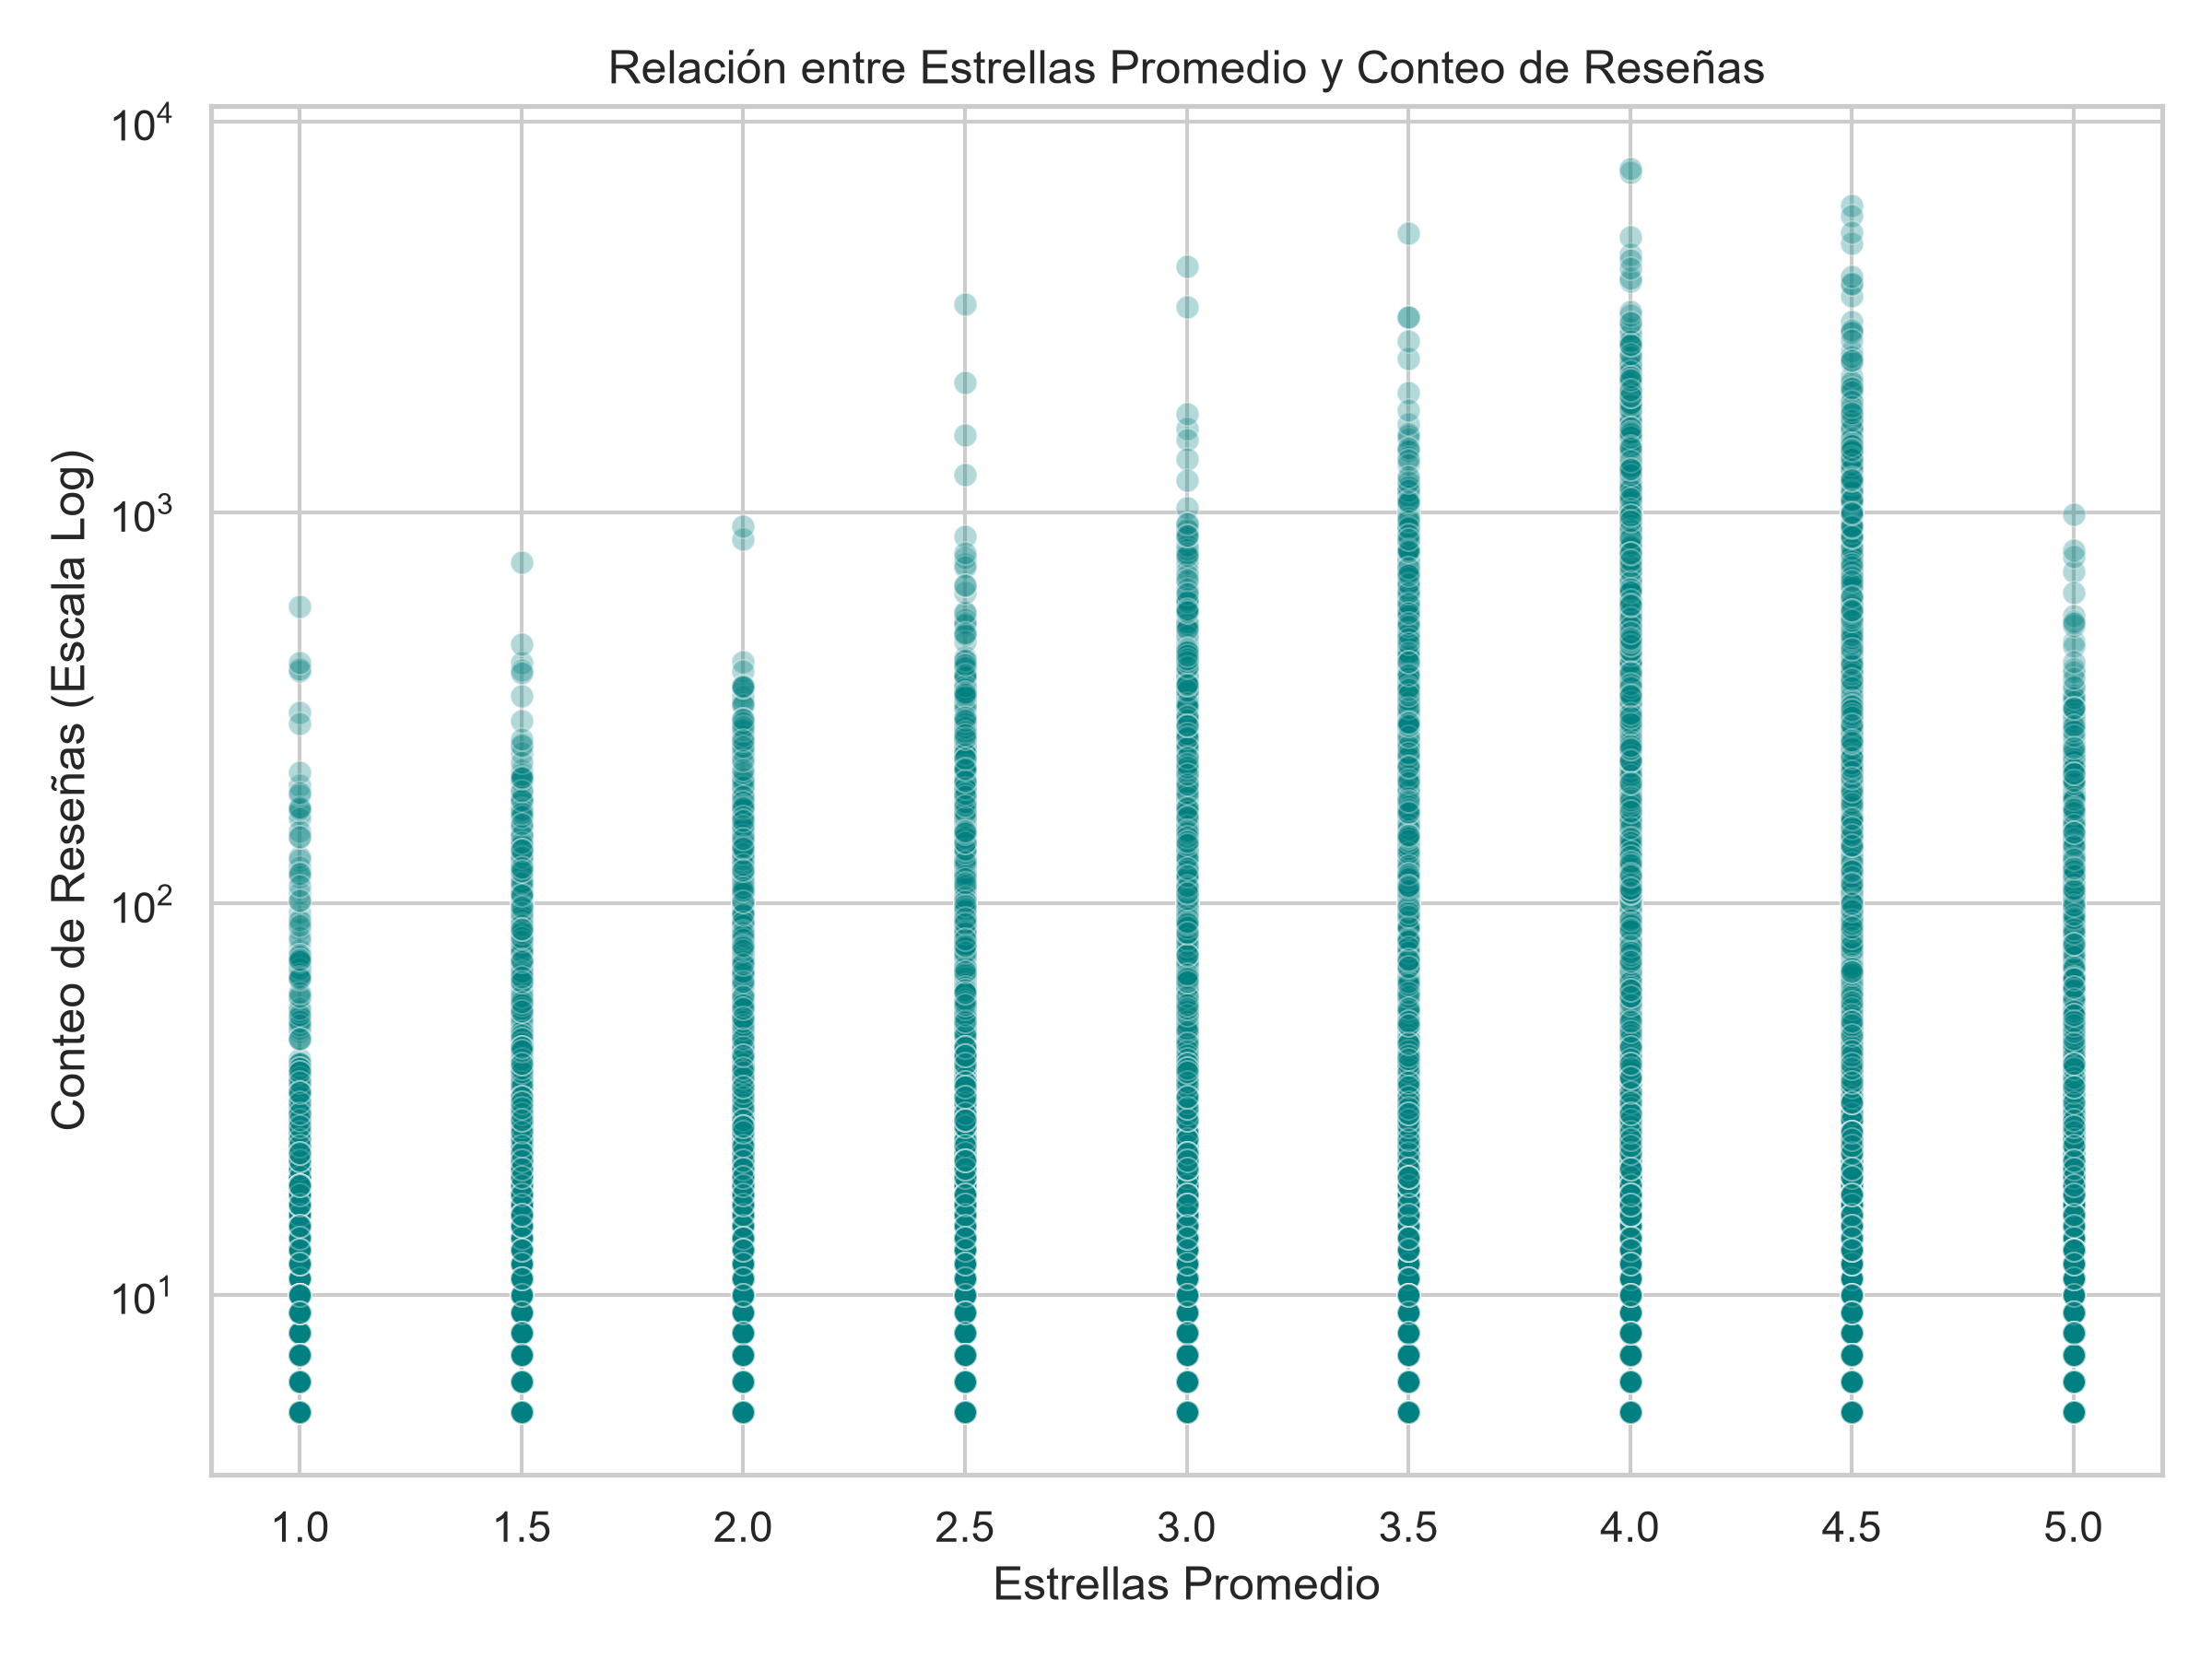


Análisis Geográfico por Segmentos (Top 5 Estados):


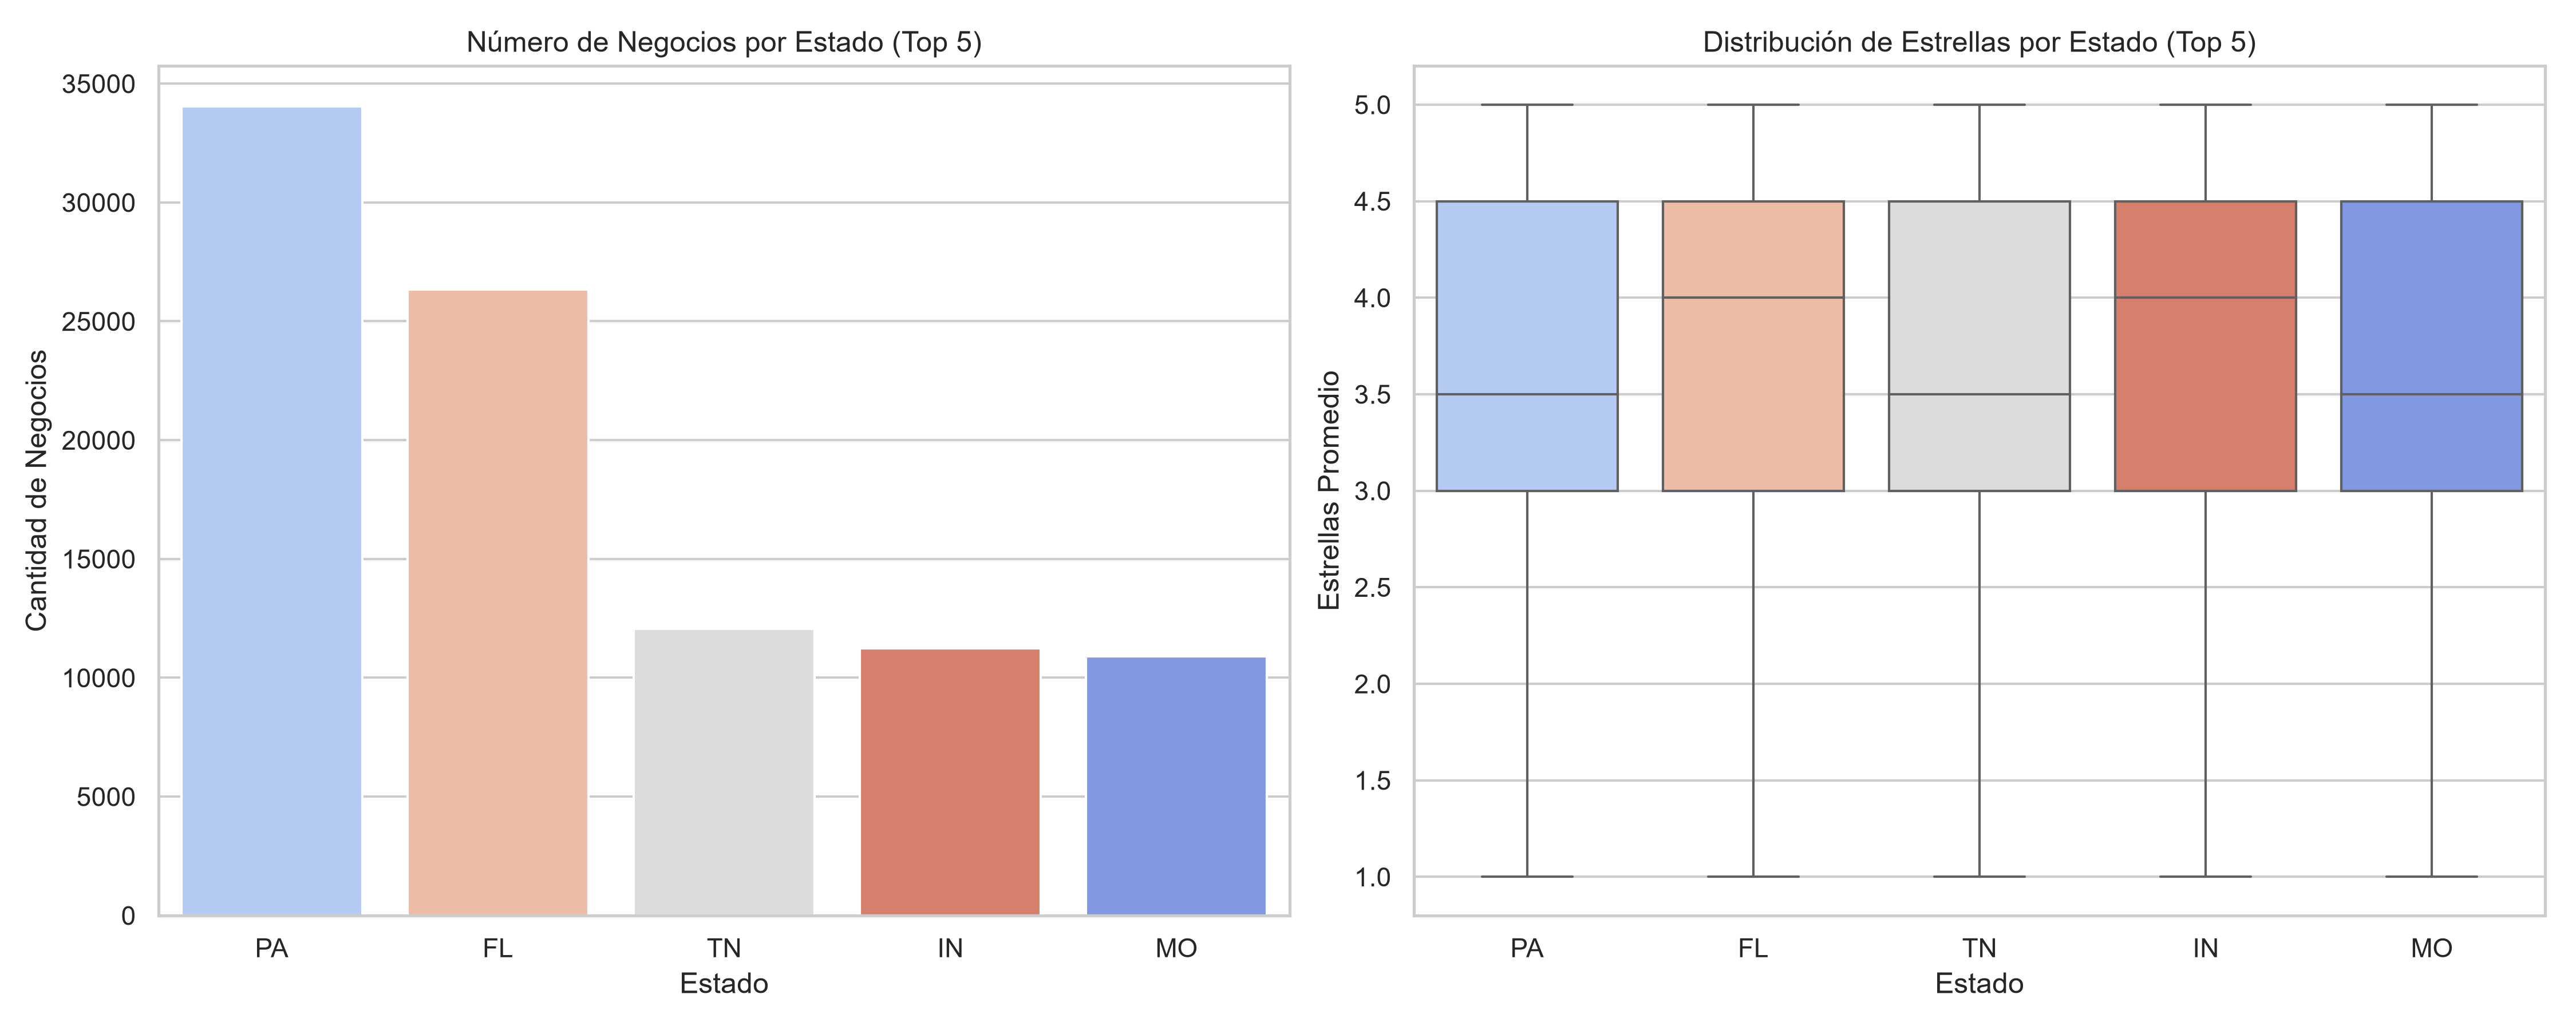

In [3]:
# ==============================================================================
# EJECUCIÓN COMPLETA DEL EDA Y LIMPIEZA
# ==============================================================================

import os
from IPython.display import Image, display as ipy_display

# Definición de rutas
REVIEW_PATH = 'Yelp-JSON/Yelp JSON/yelp_academic_dataset_review.json'
BUSINESS_PATH = 'Yelp-JSON/Yelp JSON/yelp_academic_dataset_business.json'

print("1. Cargando datos de negocios de forma eficiente...")
business_raw = load_business_efficiently(BUSINESS_PATH)
print(f"   Negocios leídos originalmente: {business_raw.shape[0]:,}")

print("\n2. Cargando muestra de reseñas mediante Reservoir Sampling...")
reviews_temp = load_reviews_efficiently(REVIEW_PATH, sample_size=300001, use_reservoir=True)
print(f"   Reseñas leídas originalmente (temporal): {reviews_temp.shape[0]:,}")

print("\n3. Ejecutando limpieza exhaustiva y normalización...")
reviews_clean, business_clean, cleaning_report = perform_exhaustive_cleaning(reviews_temp, business_raw)

print("\n=== REPORTE DE LIMPIEZA Y NORMALIZACIÓN ===")
print(f"• Reseñas iniciales: {reviews_temp.shape[0]:,}")
print(f"  - Reseñas eliminadas por NaN críticos: {cleaning_report['reviews_dropped_nan']:,}")
print(f"  - Reseñas duplicadas eliminadas: {cleaning_report['reviews_dropped_duplicates']:,}")
print(f"  - Reseñas con estrellas inválidas eliminadas: {cleaning_report['reviews_invalid_stars']:,}")
print(f"  - Reseñas huérfanas eliminadas (sin negocio asociado): {cleaning_report['reviews_orphan_removed']:,}")
print(f"• Reseñas finales tras limpieza: {reviews_clean.shape[0]:,}")
print("-" * 50)
print(f"• Negocios iniciales: {business_raw.shape[0]:,}")
print(f"  - Negocios eliminados por NaN críticos: {cleaning_report['business_dropped_nan']:,}")
print(f"  - Negocios duplicados eliminados: {cleaning_report['business_dropped_duplicates']:,}")
print(f"  - Categorías de negocios imputadas (NaN -> Uncategorized): {cleaning_report['business_imputed_categories']:,}")
print(f"  - Negocios con estrellas inválidas eliminadas: {cleaning_report['business_invalid_stars']:,}")
print(f"• Negocios finales tras limpieza: {business_clean.shape[0]:,}")
print("-" * 50)
print(f"• Umbral de outliers para Review Count de Negocios (IQR): {cleaning_report['outlier_threshold_business_reviews']:.2f}")
print(f"• Cantidad de negocios atípicos (outliers de alto volumen): {cleaning_report['business_outliers_count']:,}")

print("\n4. Seleccionando muestra final de 100,000 reseñas para la exploración visual...")
sample_df = reviews_clean.sample(min(100000, len(reviews_clean)), random_state=42)
print(f"   Muestra final lista: {sample_df.shape[0]:,} reseñas.")

print("\n5. Generando estadísticas descriptivas...")
stats = get_descriptive_statistics(sample_df, business_clean)
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print("\n• Calificaciones de Reseñas (Reviews Stars):")
for k, v in stats['review_stars_summary'].items():
    print(f"  - {k}: {v:.4f}")
print("\n• Calificaciones Promedio de Negocios (Business Stars):")
for k, v in stats['business_stars_summary'].items():
    print(f"  - {k}: {v:.4f}")
print("\n• Distribución de reseñas por negocio (Review Count):")
for k, v in stats['business_review_count_summary'].items():
    print(f"  - {k}: {v:.4f}")
print("\n• Análisis por segmentos geográficos (Top 5 Estados con más negocios):")
segment_df = pd.DataFrame(stats['state_segments'])
display(segment_df)

print("\n6. Generando y guardando gráficos exploratorios del EDA...")
plot_exploratory_charts(sample_df, business_clean, save_prefix='')
print("\nDistribución de calificaciones (Stars):")
ipy_display(Image(filename='distribucion_estrellas.png'))
print("\nDistribución del volumen de reseñas por negocio:")
ipy_display(Image(filename='distribucion_review_count.png'))
print("\nTop 15 categorías de negocio más populares:")
ipy_display(Image(filename='top_categorias.png'))
print("\nRelación entre Calificaciones y Volumen de Reseñas:")
ipy_display(Image(filename='correlacion_stars_reviews.png'))
print("\nAnálisis Geográfico por Segmentos (Top 5 Estados):")
ipy_display(Image(filename='analisis_segmentos_estados.png'))


In [4]:
export_data_for_web(reviews_clean,business_clean)

Iniciando exportación de datos para la presentación web...
¡Exportación exitosa! Datos guardados en: p2/presentation_data.js


### 2.1 Análisis de Retención y el Problema del "Cold Start" (Calculado sobre TODO el dataset)

Para justificar la elección del filtro 10-core y evaluar la retención de datos, analizaremos la distribución de reseñas iterando sobre la totalidad del dataset original (los millones de reseñas).

Como el dataset pesa varios GB, en lugar de cargarlo todo en un DataFrame de pandas de golpe, iteraremos el archivo línea por línea contando el grado de los nodos. De esta forma, calcularemos las curvas de retención exactas para $k=1$ hasta $k=10$ con altísima eficiencia de memoria, garantizando que el cálculo matemático del codo se realice sobre la verdad absoluta de los datos crudos.

Calculando frecuencias sobre todo el dataset original...


Procesando reseñas crudas: 6990280it [00:25, 278193.64it/s]



Dataset completo: 1,987,929 usuarios, 150,346 negocios, 6,990,280 reseñas.


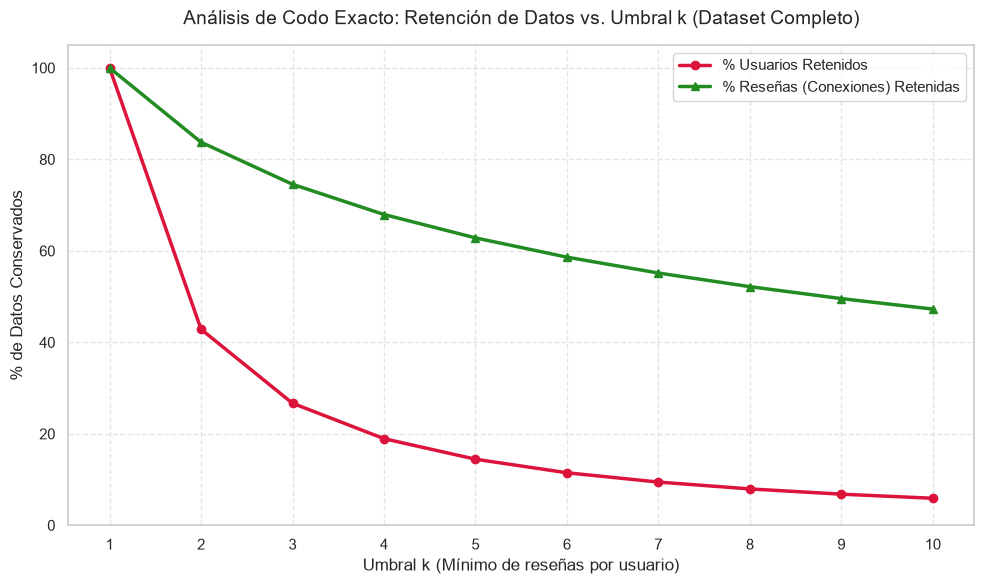

=== CÁLCULO DE CODO K-CORE ===
• Codo óptimo calculado matemáticamente (Dataset Completo): k = 4
• Reseñas (conexiones) retenidas en k=4: 67.94%
--------------------------------------------------
CONCLUSIÓN:
Aunque la matemática rigurosa nos dicte que con k bajo optimizamos la retención frente al ruido, 
en trabajos previos de minería de grafos avanzados (y como implementamos en la Parte II) 
se exige una red mucho más densa. Por ello justificamos usar k=10.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm

# 1. Stream del dataset completo para obtener el grado de cada usuario
print("Calculando frecuencias sobre todo el dataset original...")
user_counts = defaultdict(int)
business_counts = defaultdict(int)
total_reviews = 0

with open(REVIEW_PATH, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc="Procesando reseñas crudas"):
        # Usamos divisiones de strings simples en lugar de json.loads para extrema velocidad si fuera necesario,
        # pero json.loads es suficientemente rapido para 5GB.
        obj = json.loads(line)
        user_counts[obj['user_id']] += 1
        business_counts[obj['business_id']] += 1
        total_reviews += 1

total_users = len(user_counts)
total_businesses = len(business_counts)

print(f"\nDataset completo: {total_users:,} usuarios, {total_businesses:,} negocios, {total_reviews:,} reseñas.")

# Convertir a arrays de numpy para cálculos rápidos
user_degrees = np.array(list(user_counts.values()))

k_values = list(range(1, 11))
users_pct = []
reviews_pct = []

# 2. Simular retención para cada k
for k in k_values:
    active_users_mask = user_degrees >= k
    num_active_users = np.sum(active_users_mask)
    retained_reviews = np.sum(user_degrees[active_users_mask])
    
    users_pct.append((num_active_users / total_users) * 100)
    reviews_pct.append((retained_reviews / total_reviews) * 100)

# 3. Graficar curvas de retención
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plt.plot(k_values, users_pct, marker='o', linewidth=2.5, color='crimson', label='% Usuarios Retenidos')
plt.plot(k_values, reviews_pct, marker='^', linewidth=2.5, color='forestgreen', label='% Reseñas (Conexiones) Retenidas')

plt.title('Análisis de Codo Exacto: Retención de Datos vs. Umbral k (Dataset Completo)', fontsize=14, pad=15)
plt.xlabel('Umbral k (Mínimo de reseñas por usuario)', fontsize=12)
plt.ylabel('% de Datos Conservados', fontsize=12)
plt.xticks(k_values)
plt.ylim(0, 105)
plt.legend(frameon=True, facecolor='white', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# CÁLCULO MATEMÁTICO DEL CODO REAL SOBRE EL 100% DE LOS DATOS
def calculate_elbow(x, y):
    x_arr = np.array(x)
    y_arr = np.array(y)
    p1 = np.array([x_arr[0], y_arr[0]])
    p2 = np.array([x_arr[-1], y_arr[-1]])
    line_vec = p2 - p1
    line_vec_norm = line_vec / np.linalg.norm(line_vec)
    distances = []
    for i in range(len(x_arr)):
        p = np.array([x_arr[i], y_arr[i]])
        start_to_p = p - p1
        proj = np.dot(start_to_p, line_vec_norm) * line_vec_norm
        perp_vec = start_to_p - proj
        distances.append(np.linalg.norm(perp_vec))
    best_idx = np.argmax(distances)
    return x_arr[best_idx], y_arr[best_idx]

k_elbow, pct_elbow = calculate_elbow(k_values, reviews_pct)
print("=== CÁLCULO DE CODO K-CORE ===")
print(f"• Codo óptimo calculado matemáticamente (Dataset Completo): k = {k_elbow}")
print(f"• Reseñas (conexiones) retenidas en k={k_elbow}: {pct_elbow:.2f}%")
print("-" * 50)
print("CONCLUSIÓN:")
print("Aunque la matemática rigurosa nos dicte que con k bajo optimizamos la retención frente al ruido, ")
print("en trabajos previos de minería de grafos avanzados (y como implementamos en la Parte II) ")
print("se exige una red mucho más densa. Por ello justificamos usar k=10.")

In [6]:
from implementaciones.export_presentation_data import export_elbow_data
export_elbow_data(k_values, users_pct, reviews_pct)

Iniciando exportación de datos del codo k-core...
¡Datos del codo exportados con éxito a p2/elbow_data.js!


## 3. Construcción del Grafo Bipartito (10-Core)
Basado en el análisis de retención, construimos el grafo utilizando el dataset filtrado con k-core=10 (como se utiliza en la Parte II) para garantizar un grafo denso y computable.

In [7]:
from implementaciones.graphs import BipartiteGraph, BipartiteDiGraph
from implementaciones.preprocessing import load_reviews_efficiently, load_business_efficiently

In [8]:
# Carga de datos y reconstrucción del grafo bipartito en memoria
REVIEW_PATH = 'Yelp-JSON/Yelp JSON/yelp_academic_dataset_review_10core.json'
print("Cargando reviews de Yelp (Subgrafo 10-Core completo)...")
sample_df = load_reviews_efficiently(REVIEW_PATH, sample_size=None, use_reservoir=False)

print("Construyendo el grafo bipartito...")
g = BipartiteGraph()
g_directed = BipartiteDiGraph()
for _, row in sample_df.iterrows():
    g.add_bipartite_edge(row['user_id'], row['business_id'])
    g_directed.add_bipartite_edge(row['user_id'], row['business_id'])
print(f"Grafo bipartito no dirigido g listo con {len(g.adj)} usuarios/negocios.")
print(f"Grafo bipartito dirigido g_directed listo con {len(g_directed.adj)} usuarios/negocios.")


Cargando reviews de Yelp (Subgrafo 10-Core completo)...


Carga secuencial de reseñas: 800001it [00:01, 664408.32it/s]


Construyendo el grafo bipartito...
Grafo bipartito no dirigido g listo con 81398 usuarios/negocios.
Grafo bipartito dirigido g_directed listo con 81398 usuarios/negocios.


## 4. Cálculo de Métricas y Componentes Conexas


In [9]:
print("=== MÉTRICAS DEL GRAFO USUARIO-PRODUCTO ===")
nodes = g.number_of_nodes()
edges = g.number_of_edges()
users = len(g.user_nodes)
products = len(g.product_nodes)
print(f"• Nodos Totales: {nodes:,}")
print(f"  - Usuarios: {users:,}")
print(f"  - Negocios: {products:,}")
print(f"• Aristas: {edges:,}")
print(f"• Densidad Estándar: {g.density():.8f}")
print(f"• Densidad Bipartita: {g.bipartite_density():.8f}")

print("\nCalculando componentes conexas...")
import time
cc_start = time.time()
components = g.connected_components()
largest_cc = max(components, key=len)
print(f"Componentes encontradas: {len(components)}")
print(f"Tamaño de la Componente Gigante (Gcc): {len(largest_cc):,} nodos ({(len(largest_cc)/nodes)*100:.2f}% del grafo)")
print(f"Tiempo de componentes: {time.time() - cc_start:.2f} s")


=== MÉTRICAS DEL GRAFO USUARIO-PRODUCTO ===
• Nodos Totales: 81,398
  - Usuarios: 28,313
  - Negocios: 53,085
• Aristas: 759,098
• Densidad Estándar: 0.00022914
• Densidad Bipartita: 0.00050506

Calculando componentes conexas...
Componentes encontradas: 1
Tamaño de la Componente Gigante (Gcc): 81,398 nodos (100.00% del grafo)
Tiempo de componentes: 0.27 s


In [10]:
print("Calculando diámetro aproximado de Gcc...")
dia_start = time.time()
# Ejecutamos con 10 iteraciones (sweeps) para mayor precisión
diam = g.diameter(largest_cc, method='approximate', max_sweeps=10)
print(f"Diámetro estimado: {diam}")
print(f"Tiempo de cálculo de diámetro: {time.time() - dia_start:.2f} s")


Calculando diámetro aproximado de Gcc...
Diámetro estimado: 10
Tiempo de cálculo de diámetro: 5.48 s
